In [1]:
## Import block

In [2]:
!pip install gdown --quiet
!pip install rasterio --quiet
!pip install scikit-image --quiet
!pip install opencv-python --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 43.3 MB/s eta 0:00:00


In [84]:
import os
import gdown
import zipfile
import rasterio
import numpy as np
import re
import tensorflow as tf
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt

In [4]:
# sub import

In [5]:
from PIL import Image
from skimage.metrics import structural_similarity as ssim
from tensorflow.keras import layers, Model, Input
from sklearn.model_selection import train_test_split
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import backend as K

In [6]:
## Downloading the data

In [7]:
folder_url = "https://drive.google.com/file/d/13Fx0DRAu5356ke765ZXUhfoJ-kLVc5LO/view?usp=sharing"
output = "satellite_data.zip"
gdown.download(folder_url, output, fuzzy=True)

Downloading...
From (original): https://drive.google.com/uc?id=13Fx0DRAu5356ke765ZXUhfoJ-kLVc5LO
From (redirected): https://drive.google.com/uc?id=13Fx0DRAu5356ke765ZXUhfoJ-kLVc5LO&confirm=t&uuid=85b63821-c3aa-4760-8e7a-52b4b4a9df59
To: /content/satellite_data.zip
100%|██████████| 68.8M/68.8M [00:01<00:00, 48.0MB/s]


'satellite_data.zip'

In [8]:
# unzip

In [9]:
with zipfile.ZipFile(output) as zip_ref:
    zip_ref.extractall("satellite_data")

In [10]:
# storing in directories

In [11]:
data_directory = "satellite_data/satalite data/data"
images_directory = os.path.join(data_directory, "images")
labels_directory = os.path.join(data_directory, "labels")

In [12]:
# checking directories

In [13]:
print("Images directory:", images_directory)
print("Labels directory:", labels_directory)

Images directory: satellite_data/satalite data/data/images
Labels directory: satellite_data/satalite data/data/labels


In [14]:
## Data processing

In [15]:
tif_files = [os.path.join(images_directory, f) for f in os.listdir(images_directory) if f.endswith(".tif")]
png_files = [os.path.join(labels_directory, f) for f in os.listdir(labels_directory) if f.endswith(".png")]

In [16]:
# fixing names

In [17]:
def extract_id(filename):
    basename = os.path.splitext(os.path.basename(filename))[0]
    numbers = re.findall(r'\d+', basename)
    if numbers:
        return int(numbers[-1])
    else:
        return None

In [18]:
# sorting using dictionary

In [19]:
image_dict = {extract_id(f): f for f in tif_files}
mask_dict = {extract_id(f): f for f in png_files}
common_ids = sorted(set(image_dict.keys()) & set(mask_dict.keys()))

In [20]:
# ordering files

In [21]:
tif_files_sorted = [image_dict[i] for i in common_ids]
png_files_sorted = [mask_dict[i] for i in common_ids]

In [22]:
# check data

In [23]:
print("Total aligned pairs:", len(tif_files_sorted))
for i in range(len(tif_files_sorted)):
    print(f"Image: {tif_files_sorted[i]}  |  Mask: {png_files_sorted[i]}")

Total aligned pairs: 306
Image: satellite_data/satalite data/data/images/0.tif  |  Mask: satellite_data/satalite data/data/labels/0.png
Image: satellite_data/satalite data/data/images/1.tif  |  Mask: satellite_data/satalite data/data/labels/1.png
Image: satellite_data/satalite data/data/images/2.tif  |  Mask: satellite_data/satalite data/data/labels/28_2.png
Image: satellite_data/satalite data/data/images/3.tif  |  Mask: satellite_data/satalite data/data/labels/3.png
Image: satellite_data/satalite data/data/images/4.tif  |  Mask: satellite_data/satalite data/data/labels/4.png
Image: satellite_data/satalite data/data/images/5.tif  |  Mask: satellite_data/satalite data/data/labels/5.png
Image: satellite_data/satalite data/data/images/6.tif  |  Mask: satellite_data/satalite data/data/labels/6.png
Image: satellite_data/satalite data/data/images/7.tif  |  Mask: satellite_data/satalite data/data/labels/7.png
Image: satellite_data/satalite data/data/images/8.tif  |  Mask: satellite_data/satal

In [24]:
# optional arrays

In [25]:
images_files = np.array(tif_files_sorted)
labels_files = np.array(png_files_sorted)

In [26]:
# opening data

In [27]:
all_images = []
all_masks = []
for tif_path, mask_path in zip(tif_files_sorted, png_files_sorted):
    with rasterio.open(tif_path) as source:
        image = source.read()
        image = np.transpose(image, (1,2,0))
    all_images.append(image)
    mask = np.array(Image.open(mask_path))
    all_masks.append(mask)
all_images = np.array(all_images)
all_masks = np.array(all_masks)

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


In [28]:
# preview

In [29]:
print("Images shape:", all_images.shape)
print("Masks shape:", all_masks.shape)

Images shape: (306, 128, 128, 12)
Masks shape: (306, 128, 128)


In [30]:
# normalization start

In [31]:
band_mins = all_images.reshape(-1, all_images.shape[-1]).min(axis=0)
band_maxs = all_images.reshape(-1, all_images.shape[-1]).max(axis=0)
mask_min = all_masks.min()
mask_max = all_masks.max()

In [32]:
# preview

In [33]:
print("Band mins:", band_mins)
print("Band maxs:", band_maxs)
print("Mask min:", mask_min)
print("Mask max:", mask_max)

Band mins: [-1393 -1169  -722  -684  -412  -335  -258    64 -9999     8    10     0]
Band maxs: [ 6568  9659 11368 12041 15841 15252 14647   255  4245  4287   100   111]
Mask min: 0
Mask max: 1


In [34]:
# normalization

In [35]:
images_norm = (all_images - band_mins) / (band_maxs - band_mins)
masks_norm = (all_masks - mask_min) / (mask_max - mask_min)

In [36]:
# review

In [37]:
print("Normalized images shape:", images_norm.shape)
print("Normalized masks shape:", masks_norm.shape)

Normalized images shape: (306, 128, 128, 12)
Normalized masks shape: (306, 128, 128)


In [38]:
## Best channel selection

In [39]:
num_bands = images_norm.shape[-1]
pcc_scores = []
mse_scores = []
ssim_scores = []
for b in range(num_bands):
    band_values = images_norm[..., b]
    band_values_flat = band_values.reshape(-1)
    mask_values_flat = masks_norm.reshape(-1)
    pcc = np.corrcoef(band_values_flat, mask_values_flat)[0,1]
    mse = np.mean((band_values_flat- mask_values_flat) ** 2)
    ssim_per_image = []
    for i in range(images_norm.shape[0]):
        ssim_value = ssim(band_values[i], masks_norm[i], data_range=1.0)
        ssim_per_image.append(ssim_value)
    ssim_average = np.mean(ssim_per_image)
    pcc_scores.append(pcc)
    mse_scores.append(mse)
    ssim_scores.append(ssim_average)

In [40]:
# convert to arrays

In [41]:
pcc_scores = np.array(pcc_scores)
mse_scores = np.array(mse_scores)
ssim_scores = np.array(ssim_scores)

In [42]:
# band ranking (high pcc, low mse, high ssim)

In [43]:
combined_score = pcc_scores - mse_scores + ssim_scores
best_indices = np.argsort(-combined_score)

In [44]:
# results

In [45]:
print("Band ranking by combined score:")
for idx in best_indices:
    print(f"Band {idx} | PCC={pcc_scores[idx]:.3f}, MSE={mse_scores[idx]:.3f}, SSIM={ssim_scores[idx]:.3f}")
top6 = best_indices[:12]
print("Top 6 bands:", top6)

Band ranking by combined score:
Band 11 | PCC=0.577, MSE=0.158, SSIM=0.703
Band 10 | PCC=0.468, MSE=0.151, SSIM=0.174
Band 7 | PCC=0.279, MSE=0.198, SSIM=0.396
Band 2 | PCC=0.006, MSE=0.211, SSIM=0.045
Band 1 | PCC=-0.028, MSE=0.205, SSIM=0.052
Band 3 | PCC=-0.023, MSE=0.212, SSIM=0.044
Band 0 | PCC=-0.073, MSE=0.197, SSIM=0.071
Band 9 | PCC=-0.174, MSE=0.260, SSIM=0.132
Band 8 | PCC=-0.253, MSE=0.427, SSIM=0.149
Band 6 | PCC=-0.465, MSE=0.246, SSIM=0.014
Band 5 | PCC=-0.570, MSE=0.249, SSIM=0.010
Band 4 | PCC=-0.633, MSE=0.244, SSIM=0.016
Top 6 bands: [11 10  7  2  1  3  0  9  8  6  5  4]


In [46]:
## Building the model

In [ ]:
# iou setup

In [67]:
class MeanIoU(tf.keras.metrics.Metric):
    def __init__(self, name='mean_iou', threshold=0.5, **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold
        self.intersection = self.add_weight(name='intersection', initializer='zeros', dtype=tf.float32)
        self.union = self.add_weight(name='union', initializer='zeros', dtype=tf.float32)

    def update_state(self, y_true, y_pred, sample_weight=None):
        # y_true: (batch,H,W,1) floats 0/1 ; y_pred: (batch,H,W,1) float probabilities
        y_pred = tf.cast(y_pred > self.threshold, tf.float32)
        y_true = tf.cast(y_true, tf.float32)

        # flatten per batch
        inter = tf.reduce_sum(y_true * y_pred)
        uni = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - inter

        self.intersection.assign_add(tf.cast(inter, tf.float32))
        self.union.assign_add(tf.cast(uni, tf.float32))

    def result(self):
        return (self.intersection + 1e-6) / (self.union + 1e-6)

    def reset_states(self):
        self.intersection.assign(0.0)
        self.union.assign(0.0)

In [47]:
# model

In [68]:
def unet_model_binary(input_size=(128, 128, 12)):
    inputs = Input(input_size)
    # encoder
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)

    # decoder
    u6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    # output layer
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model

In [49]:
# splitting the data

In [69]:
target_size = (128, 128)
selected_bands = top6
images_resized = []
masks_resized = []
for img, mask in zip(images_norm, masks_norm):
    img_sel = img[..., selected_bands]
    img_resized = cv2.resize(img_sel, target_size, interpolation=cv2.INTER_LINEAR)
    mask_resized = cv2.resize(mask, target_size, interpolation=cv2.INTER_NEAREST)
    images_resized.append(img_resized.astype(np.float32))
    masks_resized.append(mask_resized.astype(np.float32)[..., np.newaxis])
images_resized = np.array(images_resized, dtype=np.float32)
masks_resized = np.array(masks_resized, dtype=np.float32)

In [51]:
# preview

In [70]:
print("Processed images:", images_resized.shape)
print("Processed masks:", masks_resized.shape)

Processed images: (306, 128, 128, 12)
Processed masks: (306, 128, 128, 1)


In [53]:
# data split

In [71]:
x_train, x_val, y_train, y_val = train_test_split(
    images_resized, masks_resized, test_size=0.2, random_state=42)

loss

In [72]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

In [56]:
# compiling model

In [73]:
model = unet_model_binary(input_size=(128, 128, 12))
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=[dice_coef, MeanIoU(name='mean_iou'), 'accuracy'])

In [58]:
# summary

In [59]:
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      6,976 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 512) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8,      │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8,      │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │  2,097,664 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose

 Total params: 31,036,929 (118.40 MB)

 Trainable params: 31,036,929 (118.40 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
# gpu test

In [61]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 1


In [ ]:
# augmentation

In [77]:
data_gen_args = dict(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

image_datagen = ImageDataGenerator(**data_gen_args)
mask_datagen  = ImageDataGenerator(**data_gen_args)
seed = 42
batch_size = 8
image_generator = image_datagen.flow(x_train, batch_size=batch_size, seed=seed)
mask_generator  = mask_datagen.flow(y_train, batch_size=batch_size, seed=seed)
train_generator = zip(image_generator, mask_generator)
def train_generator():
    for img, mask in zip(image_generator, mask_generator):
        yield img, mask
def paired_generator(img_gen, mask_gen):
    while True:
        imgs = next(img_gen)
        masks = next(mask_gen)
        yield imgs, masks

train_gen = paired_generator(image_generator, mask_generator)
steps_per_epoch = max(1, len(x_train) // batch_size)

In [ ]:
# callbacks

In [78]:
checkpoint = ModelCheckpoint(
    "best_unet.keras",
    monitor="val_mean_iou",   # NOTE: monitor IoU now
    save_best_only=True,
    mode="max",               # higher IoU is better
    verbose=1)
early_stop = EarlyStopping(monitor="val_mean_iou", patience=12, mode="max", restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor="val_mean_iou", factor=0.5, patience=6, mode="max", verbose=1)

In [64]:
# training the model

In [82]:
history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=(x_val, y_val),
    epochs=100,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.7000 - dice_coef: 0.3430 - loss: 1.2996 - mean_iou: 0.2355
Epoch 1: val_mean_iou improved from -inf to 0.47794, saving model to best_unet.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 25s 445ms/step - accuracy: 0.7026 - dice_coef: 0.3429 - loss: 1.2974 - mean_iou: 0.2372 - val_accuracy: 0.8364 - val_dice_coef: 0.4963 - val_loss: 0.9391 - val_mean_iou: 0.4779 - learning_rate: 1.0000e-04
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8387 - dice_coef: 0.5669 - loss: 0.8095 - mean_iou: 0.5151
Epoch 2: val_mean_iou did not improve from 0.47794
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 178ms/step - accuracy: 0.8386 - dice_coef: 0.5676 - loss: 0.8088 - mean_iou: 0.5157 - val_accuracy: 0.8376 - val_dice_coef: 0.6225 - val_loss: 0.7713 - val_mean_iou: 0.4573 - learning_rate: 1.0000e-04
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.8544 - dice_coef: 0.6233 - loss: 0.7059 - mean_iou: 0.5647
Epoch 3: val_mean_iou 

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Mean IoU: 0.5348
Mean Dice: 0.6010
Precision: 0.6808
Recall: 0.5970
F1 Score: 0.6010


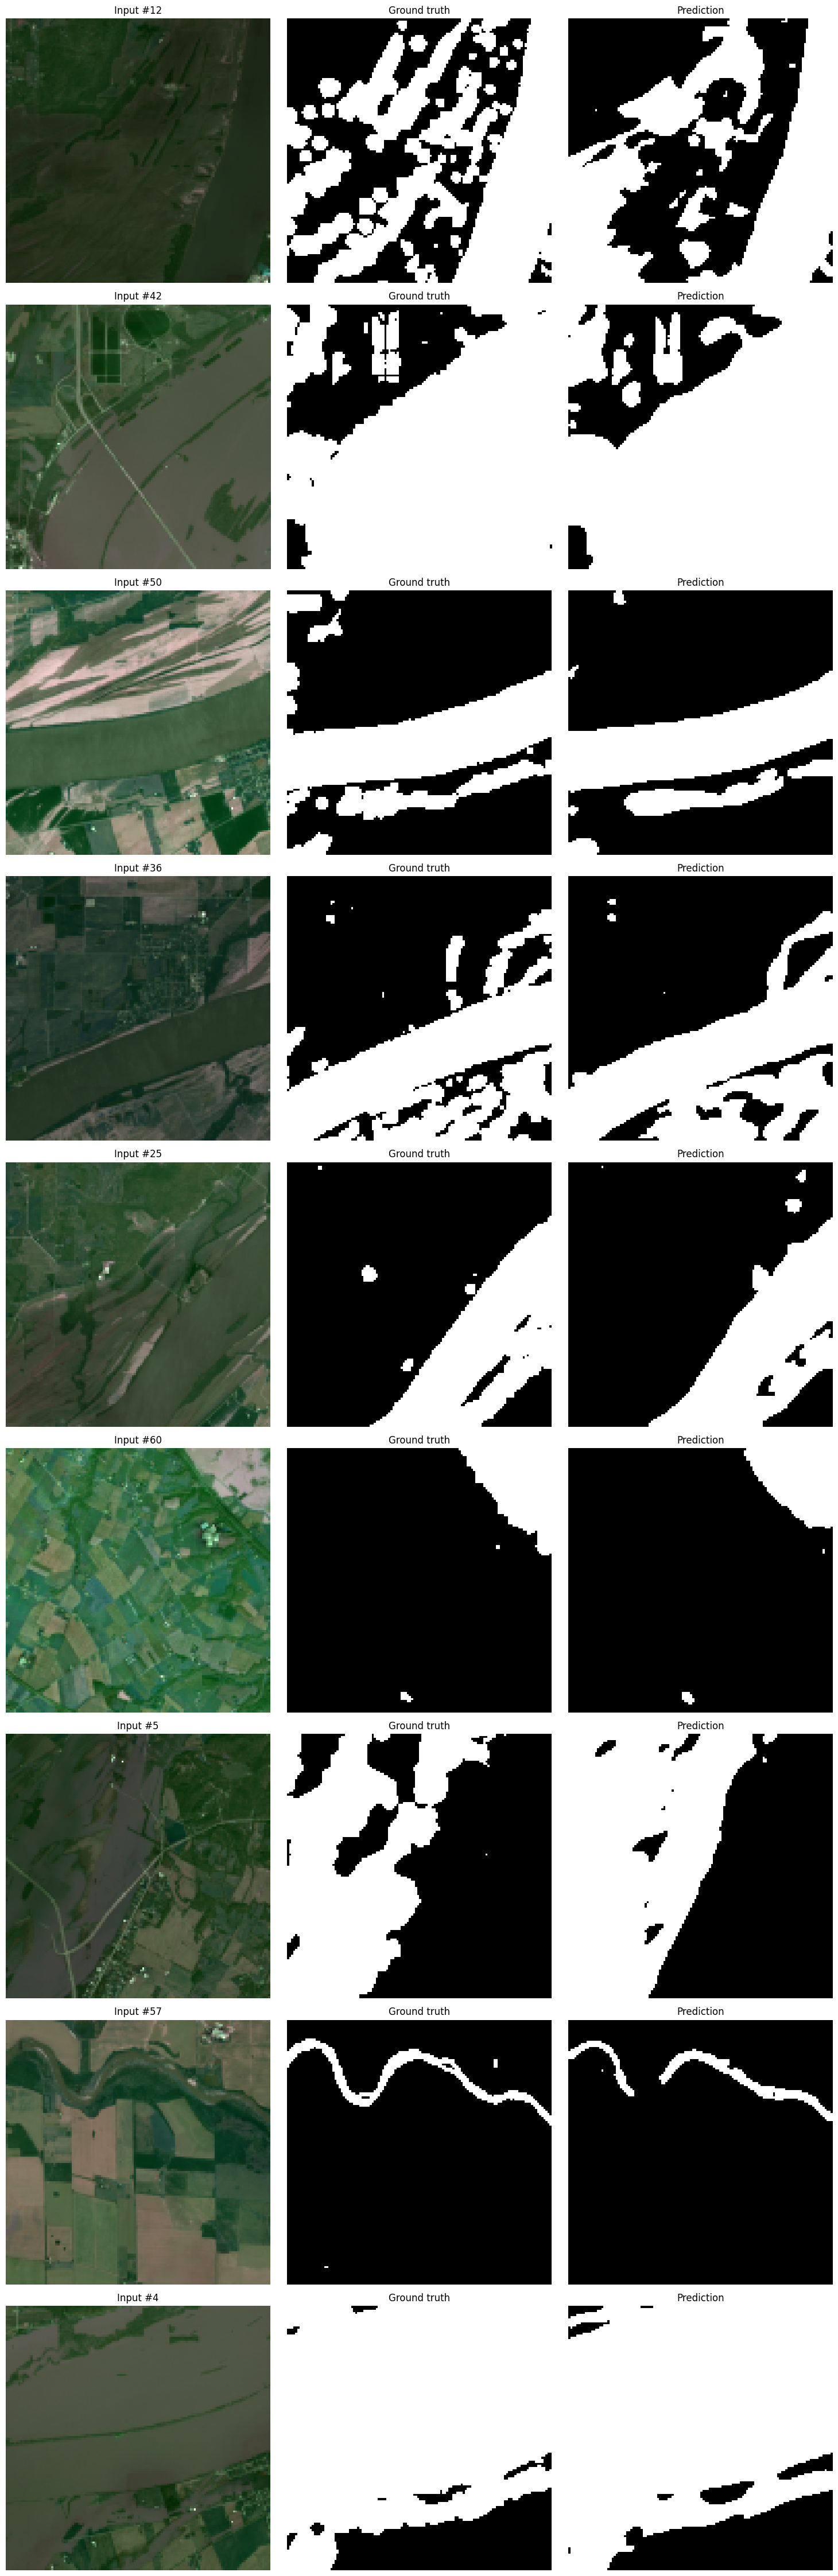

In [86]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

def iou_score_np(y_true, y_pred, threshold=0.5):
    y_pred = (y_pred > threshold).astype(np.uint8)
    inter = np.logical_and(y_true==1, y_pred==1).sum()
    uni = np.logical_or(y_true==1, y_pred==1).sum()
    return inter / (uni + 1e-6)

def dice_np(y_true, y_pred, threshold=0.5):
    y_pred = (y_pred > threshold).astype(np.uint8)
    inter = (y_true * y_pred).sum()
    return (2. * inter) / (y_true.sum() + y_pred.sum() + 1e-6)

ious, dices, precisions, recalls, f1s = [], [], [], [], []
examples = 9    # number of examples to visualize (randomized)
rng = np.random.default_rng(42)

# Predict on validation set in batches for memory
preds = model.predict(x_val, batch_size=8, verbose=1)  # shape (N,H,W,1)

for i in range(len(x_val)):
    mask = (y_val[i,...,0] > 0.5).astype(np.uint8)
    pred = preds[i,...,0]           # probabilities

    ious.append(iou_score_np(mask, pred))
    dices.append(dice_np(mask, pred))

    y_true_flat = mask.flatten().astype(np.uint8)
    y_pred_flat = (pred > 0.5).astype(np.uint8).flatten()

    precisions.append(precision_score(y_true_flat, y_pred_flat, zero_division=0))
    recalls.append(recall_score(y_true_flat, y_pred_flat, zero_division=0))
    f1s.append(f1_score(y_true_flat, y_pred_flat, zero_division=0))

# Print aggregate metrics
print(f"Mean IoU: {np.mean(ious):.4f}")
print(f"Mean Dice: {np.mean(dices):.4f}")
print(f"Precision: {np.mean(precisions):.4f}")
print(f"Recall: {np.mean(recalls):.4f}")
print(f"F1 Score: {np.mean(f1s):.4f}")

# Visualize some randomized examples (first column RGB from selected bands)
sample_idxs = rng.choice(len(x_val), size=min(examples, len(x_val)), replace=False)
plt.figure(figsize=(15, 5*len(sample_idxs)))
for idx_i, ii in enumerate(sample_idxs):
    plt_idx = idx_i + 1
    rgb_bands = [5,4,3]
    rgb_img = x_val[ii][..., rgb_bands]  # rgb_bands is index set into your selected channels, 0-based
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min() + 1e-9)

    plt.subplot(len(sample_idxs), 3, 3*idx_i+1)
    plt.imshow(rgb_img)
    plt.title(f"Input #{ii}")
    plt.axis("off")

    plt.subplot(len(sample_idxs), 3, 3*idx_i+2)
    plt.imshow(y_val[ii,...,0], cmap='gray')
    plt.title("Ground truth")
    plt.axis("off")

    plt.subplot(len(sample_idxs), 3, 3*idx_i+3)
    plt.imshow(preds[ii,...,0] > 0.5, cmap='gray')
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()
